In [1]:
import numpy as np
import matplotlib.pyplot as plt 

### The Rossler system

The following notebook investigates where the Hopf bifurcation occurs within the Rossler system. The first method for this is by setting a=b=0.2 as conventional, then  calculating Jacobians and eigenvalues for a range of c-values. After taking the positive branch and graphing, it becomes clear that the bifurcation occurs at c=2a each time, so long as a and b are equal.

In [2]:
#Defining necessary arrays
a = 0.2
b = 0.2
c= np.linspace(2*a,8,1001)
x_plus = np.zeros(len(c))
y_plus = np.zeros(len(c))
z_plus = np.zeros(len(c))
x_minus = np.zeros(len(c))
y_minus = np.zeros(len(c))
z_minus = np.zeros(len(c))
A_plus = np.zeros((len(c),3,3))
A_minus = np.zeros((len(c),3,3))
eigenvals_plus = np.zeros((len(c),3), dtype = complex)
eigenvals_minus = np.zeros((len(c),3), dtype = complex)
eigenvec_plus = np.zeros ((len(c),3,3), dtype = complex)
eigenvec_minus = np.zeros ((len(c),3,3), dtype = complex)
for i in range (len(c)):
    #Updating fixed points
    z_plus[i] = (c[i] + np.sqrt((c[i])**2 - (4*a*b)))/(2*a)
    x_plus[i] = a*z_plus[i]
    y_plus[i] = - z_plus[i]
    
    z_minus[i] = (c[i] - np.sqrt((c[i])**2 - (4*a*b)))/(2*a)
    x_minus[i] = a*z_minus[i]
    y_minus[i] = - z_minus[i]
    #Calculating eigenvalues,eigenvectors
    A_plus[i] = np.array ([[0,-1,-1],
         [1,a,0],
         [z_plus[i],0,x_plus[i]-c[i]]])
    eigenvals_plus[i,:],eigenvec_plus[i] = np.linalg.eig(A_plus[i])

    A_minus[i] = np.array ([[0,-1,-1],
         [1,a,0],
         [z_minus[i],0,x_minus[i]-c[i]]])
    eigenvals_minus[i,:],eigenvec_minus[i] = np.linalg.eig(A_minus[i])

Hopf bifurcation happens at c = 0.4


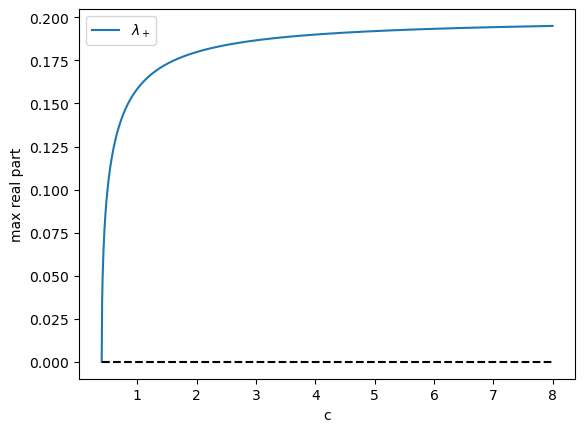

In [3]:
#Taking maximum real part of eigenvalues 
max_real_plus = np.max(np.real(eigenvals_plus), axis=1)
max_real_minus = np.max(np.real(eigenvals_minus), axis=1)

#Plotting 
plt.plot(c, max_real_plus, label=f"$\lambda_+$")
plt.plot(c,np.zeros(len(c)),linestyle = "dashed",color = "k")
plt.xlabel("c")
plt.ylabel("max real part")
plt.legend()
print(f"Hopf bifurcation happens at c = {2*a}")

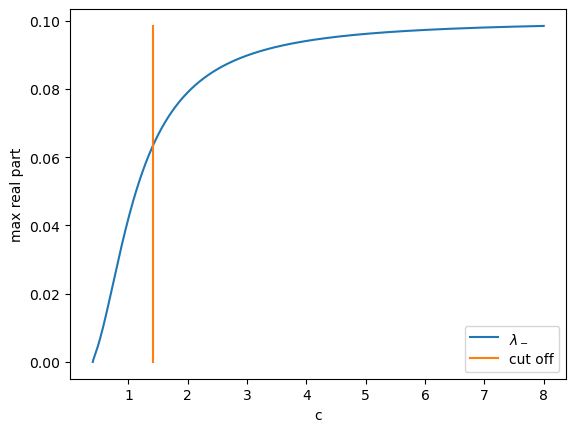

In [4]:
plt.plot(c, max_real_minus, label = f"$\lambda_-$")
plt.plot(np.zeros(len(c))+np.sqrt(2),max_real_minus, label = "cut off")
plt.xlabel("c")
plt.ylabel("max real part")
plt.legend()

An alternative way to see where the Hopf bifurcation happens is to use the Routh-Hurwitz stability criterion - as detailed in the group report. In short, if A1*A2 - A3 = 0, it means the given value of c corresponds to the bifurcation point. The code below can be used to test that, for each equal value of a and b, c=2a will come out as the bifurcation point and the condition will return zero.

In [5]:
#Using Routh-Hurwitz to prove result

#Finding fixed point
def fixed_z(a,b,c):
    discrim = c**2 - 4*a*b
    if discrim < 0 :
        #Avoiding complex numbers
        return None
    z_fixed = (c + np.sqrt(discrim))/(2*a)
    return z_fixed

In [6]:
# Inputting alleged Hopf bifurcation point
a=0.2
b=0.2
c=2*a
zF = fixed_z(a,b,c)
yF = -zF
xF = a*zF
dis = ((a+xF-c)**2)*((a*c-a*xF-1-zF)**2) - 4*((-(a*c-a*xF-1-zF))**3) -4*((-(a+xF-c))**3)*(-(xF-c) - a*zF) -27*((-(xF-c) - a*zF)**2)+18*(-(a*c-a*xF-1-zF))*(-(a*c-a*xF-1-zF))*(-(xF-c) - a*zF)
A1 = c - a - a*zF
A2 = a*(a*zF - c) + 1 + zF
A3 = c - 2*a*zF
print(A1*A2-A3)

0.0
